# Assignment 2 – MEG Brain State Classification
### Data Exploration

**Goal:** Classify 4 brain states from MEG recordings: `rest`, `task_motor`, `task_story_math`, `task_working_memory`.

Two tasks:
- **Intra-subject**: train & test on the same subject (105923)
- **Cross-subject**: train on subjects 113922 & 164636, test on unseen subjects

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import glob
from pathlib import Path
from collections import defaultdict

DATA_ROOT = Path('../data')
INTRA_TRAIN = DATA_ROOT / 'Intra' / 'train'
INTRA_TEST  = DATA_ROOT / 'Intra' / 'test'
CROSS_TRAIN = DATA_ROOT / 'Cross' / 'train'
CROSS_TEST1 = DATA_ROOT / 'Cross' / 'test1'
CROSS_TEST2 = DATA_ROOT / 'Cross' / 'test2'
CROSS_TEST3 = DATA_ROOT / 'Cross' / 'test3'

TASK_LABELS = {
    'rest': 0,
    'task_motor': 1,
    'task_story_math': 2,
    'task_working_memory': 3,
}
LABEL_NAMES = {v: k for k, v in TASK_LABELS.items()}
SAMPLE_RATE = 2034  # Hz

In [2]:
def get_dataset_name(filepath):
    name = Path(filepath).stem          # e.g. rest_105923_1
    parts = name.split('_')[:-1]        # drop trailing chunk number
    return '_'.join(parts)

def load_h5(filepath):
    filepath = str(filepath)
    with h5py.File(filepath, 'r') as f:
        ds_name = get_dataset_name(filepath)
        matrix = f.get(ds_name)[()]
    return matrix  # shape (248, 35624)

def get_label(filepath):
    name = Path(filepath).name
    for task, label in TASK_LABELS.items():
        if name.startswith(task):
            return label
    raise ValueError(f'Unknown task in filename: {filepath}')

def list_files(folder):
    return sorted(Path(folder).glob('*.h5'))

## 1. Dataset inventory

In [3]:
splits = {
    'Intra/train': INTRA_TRAIN,
    'Intra/test':  INTRA_TEST,
    'Cross/train': CROSS_TRAIN,
    'Cross/test1': CROSS_TEST1,
    'Cross/test2': CROSS_TEST2,
    'Cross/test3': CROSS_TEST3,
}

print(f"{'Split':<20} {'Total':>6}  {'rest':>6}  {'motor':>6}  {'math':>6}  {'memory':>8}")
print('-' * 60)
for split_name, folder in splits.items():
    files = list_files(folder)
    counts = defaultdict(int)
    subjects = set()
    for f in files:
        label = get_label(f)
        counts[label] += 1
        # extract subject id
        parts = f.stem.split('_')
        # subject id is the 6-digit number
        for p in parts:
            if p.isdigit() and len(p) == 6:
                subjects.add(p)
    print(f"{split_name:<20} {len(files):>6}  "
          f"{counts[0]:>6}  {counts[1]:>6}  {counts[2]:>6}  {counts[3]:>8}  "
          f"subjects={sorted(subjects)}")

Split                 Total    rest   motor    math    memory
------------------------------------------------------------
Intra/train              32       8       8       8         8  subjects=['105923']
Intra/test                8       2       2       2         2  subjects=['105923']
Cross/train              64      16      16      16        16  subjects=['113922', '164636']
Cross/test1              16       4       4       4         4  subjects=['162935']
Cross/test2              16       4       4       4         4  subjects=['707749']
Cross/test3              16       4       4       4         4  subjects=['725751', '735148']


## 2. Inspect a single recording

In [4]:
sample_file = list_files(INTRA_TRAIN)[0]
matrix = load_h5(sample_file)

print(f'File   : {sample_file.name}')
print(f'Shape  : {matrix.shape}  (sensors x time_steps)')
print(f'Dtype  : {matrix.dtype}')
print(f'Duration: {matrix.shape[1] / SAMPLE_RATE:.2f} s  at {SAMPLE_RATE} Hz')
print(f'\nValue range (raw):')
print(f'  min={matrix.min():.4e}  max={matrix.max():.4e}  mean={matrix.mean():.4e}  std={matrix.std():.4e}')

File   : rest_105923_1.h5
Shape  : (248, 35624)  (sensors x time_steps)
Dtype  : float64
Duration: 17.51 s  at 2034 Hz

Value range (raw):
  min=-2.7883e-11  max=1.3240e-11  mean=4.0944e-14  std=4.9091e-12


## 3. Visualise raw sensor signals

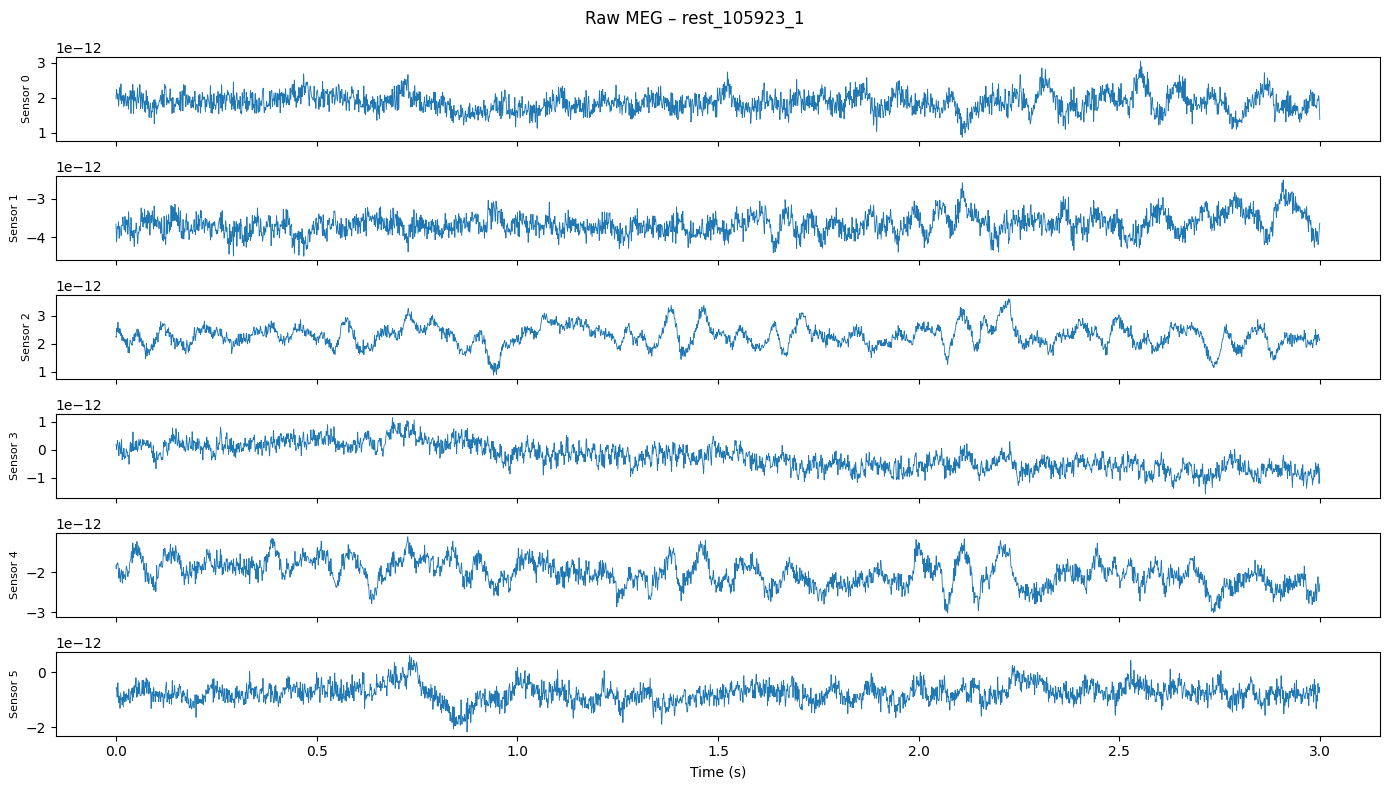

In [5]:
N_SENSORS_PLOT = 6
T_SECONDS = 3  # show first 3 seconds
T_SAMPLES = T_SECONDS * SAMPLE_RATE
time_axis = np.arange(T_SAMPLES) / SAMPLE_RATE

fig, axes = plt.subplots(N_SENSORS_PLOT, 1, figsize=(14, 8), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(time_axis, matrix[i, :T_SAMPLES], linewidth=0.6)
    ax.set_ylabel(f'Sensor {i}', fontsize=8)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
axes[-1].set_xlabel('Time (s)')
fig.suptitle(f'Raw MEG – {sample_file.stem}', fontsize=12)
plt.tight_layout()
plt.show()

## 4. One file per task – side-by-side signal comparison

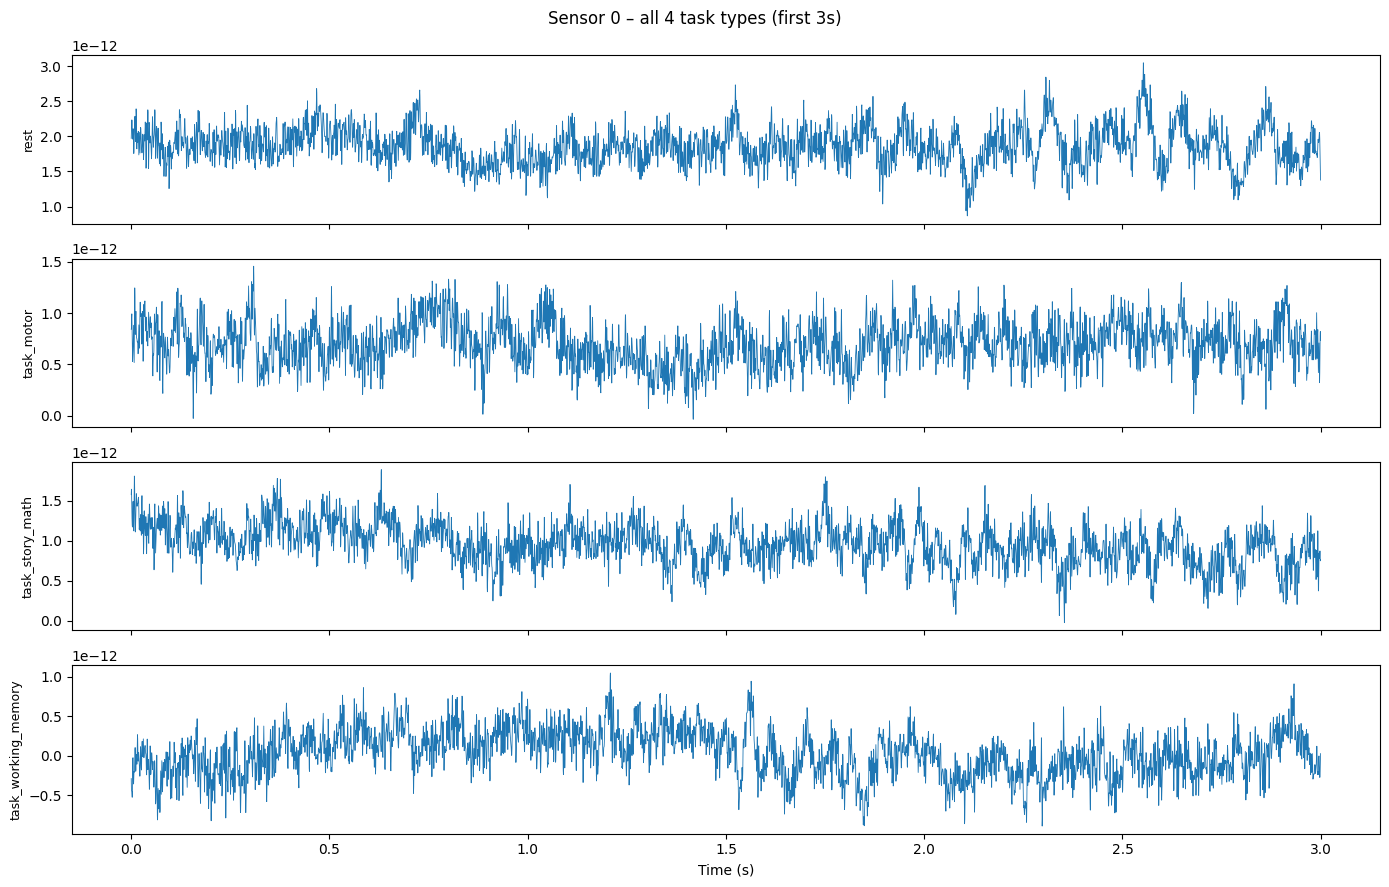

In [6]:
task_files = {}
for f in list_files(INTRA_TRAIN):
    label = get_label(f)
    if label not in task_files:
        task_files[label] = f

SENSOR_IDX = 0  # pick one sensor to visualise

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
for label, ax in zip(sorted(task_files), axes):
    m = load_h5(task_files[label])
    ax.plot(time_axis, m[SENSOR_IDX, :T_SAMPLES], linewidth=0.6)
    ax.set_ylabel(LABEL_NAMES[label], fontsize=9)
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
axes[-1].set_xlabel('Time (s)')
fig.suptitle(f'Sensor {SENSOR_IDX} – all 4 task types (first {T_SECONDS}s)', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Power spectral density per task

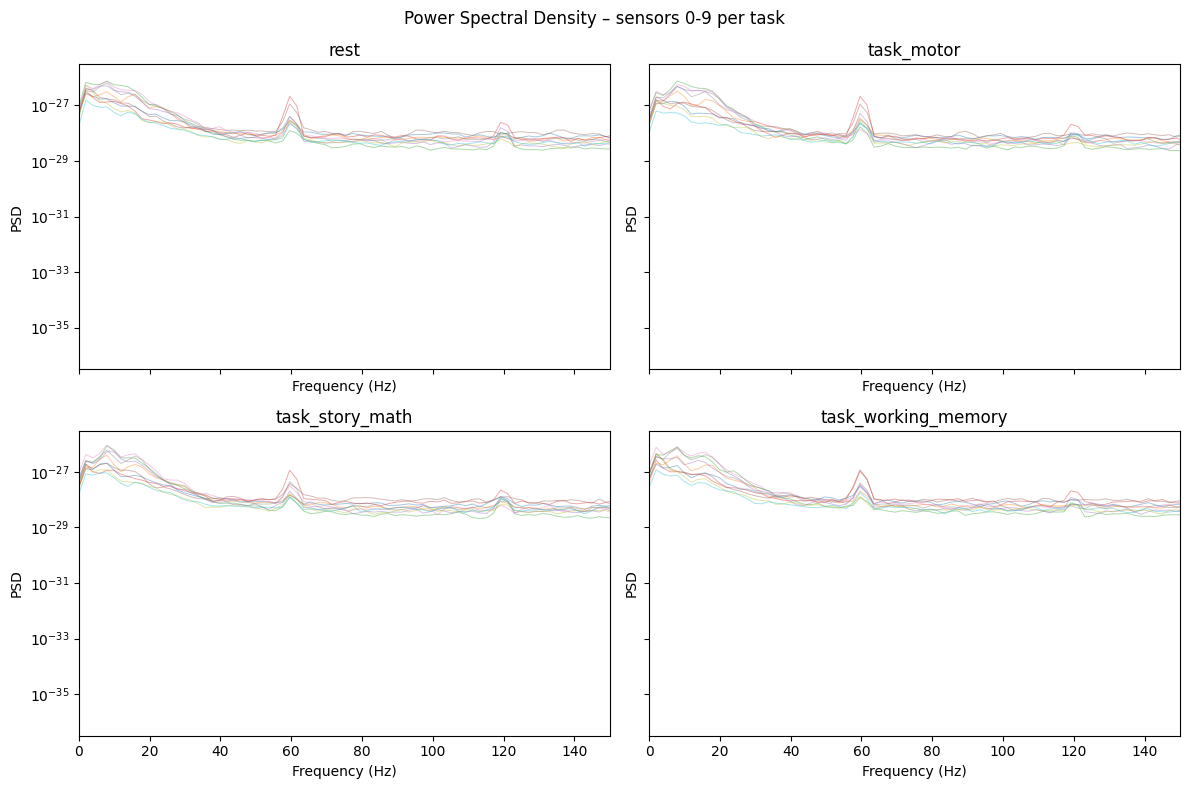

In [7]:
from scipy.signal import welch

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for label, ax in zip(sorted(task_files), axes):
    m = load_h5(task_files[label])
    # average PSD over first 10 sensors
    for s in range(10):
        f_hz, psd = welch(m[s, :], fs=SAMPLE_RATE, nperseg=1024)
        ax.semilogy(f_hz, psd, alpha=0.4, linewidth=0.7)
    ax.set_title(LABEL_NAMES[label])
    ax.set_xlim(0, 150)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('PSD')

fig.suptitle('Power Spectral Density – sensors 0-9 per task', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Sensor correlation heatmap

/var/folders/zj/ksrylh415zs8zxjjb3c3gsvw0000gn/T/ipykernel_74031/3636198856.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


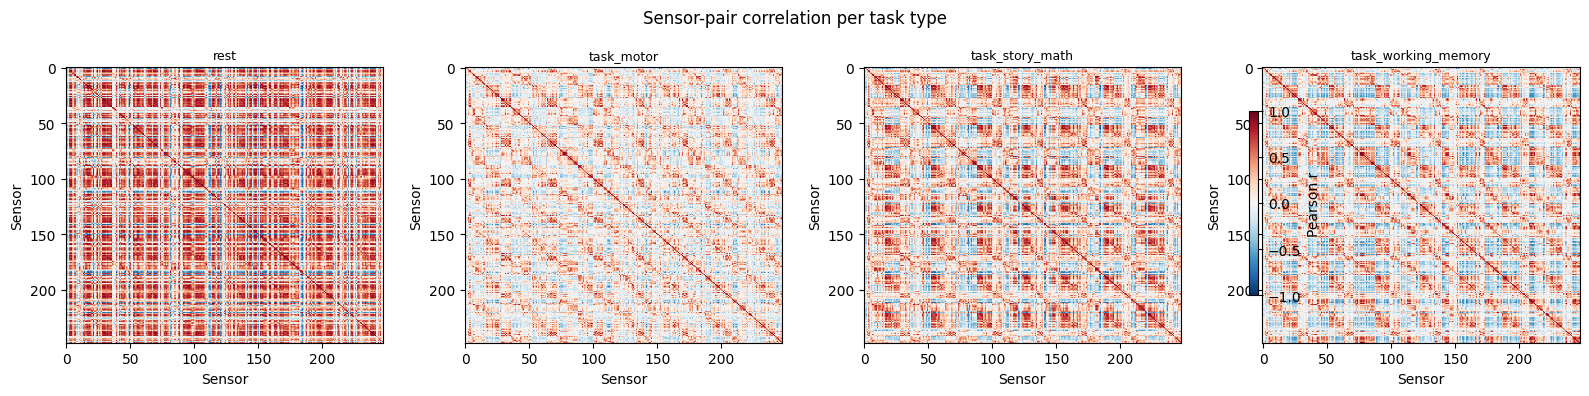

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for label, ax in zip(sorted(task_files), axes):
    m = load_h5(task_files[label])  # (248, T)
    # correlate across all 248 sensors (use full time)
    corr = np.corrcoef(m)  # (248, 248)
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
    ax.set_title(LABEL_NAMES[label], fontsize=9)
    ax.set_xlabel('Sensor')
    ax.set_ylabel('Sensor')

fig.colorbar(im, ax=axes, shrink=0.6, label='Pearson r')
fig.suptitle('Sensor-pair correlation per task type', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Preprocessing: normalization & downsampling

In [9]:
def zscore_normalize(matrix):
    """Time-wise Z-score: each sensor normalised over its own time axis."""
    mu  = matrix.mean(axis=1, keepdims=True)
    std = matrix.std(axis=1, keepdims=True) + 1e-8
    return (matrix - mu) / std

def minmax_normalize(matrix):
    mn  = matrix.min(axis=1, keepdims=True)
    mx  = matrix.max(axis=1, keepdims=True)
    return (matrix - mn) / (mx - mn + 1e-8)

def downsample(matrix, factor=4):
    """Simple decimation: keep every `factor`-th sample."""
    return matrix[:, ::factor]

raw  = load_h5(sample_file)
norm = zscore_normalize(raw)
ds   = downsample(norm, factor=4)

print(f'Raw shape   : {raw.shape}   range [{raw.min():.2e}, {raw.max():.2e}]')
print(f'Z-scored    : {norm.shape}  range [{norm.min():.2f}, {norm.max():.2f}]')
print(f'Downsampled : {ds.shape}   effective rate {SAMPLE_RATE//4} Hz')

Raw shape   : (248, 35624)   range [-2.79e-11, 1.32e-11]
Z-scored    : (248, 35624)  range [-0.00, 0.00]
Downsampled : (248, 8906)   effective rate 508 Hz


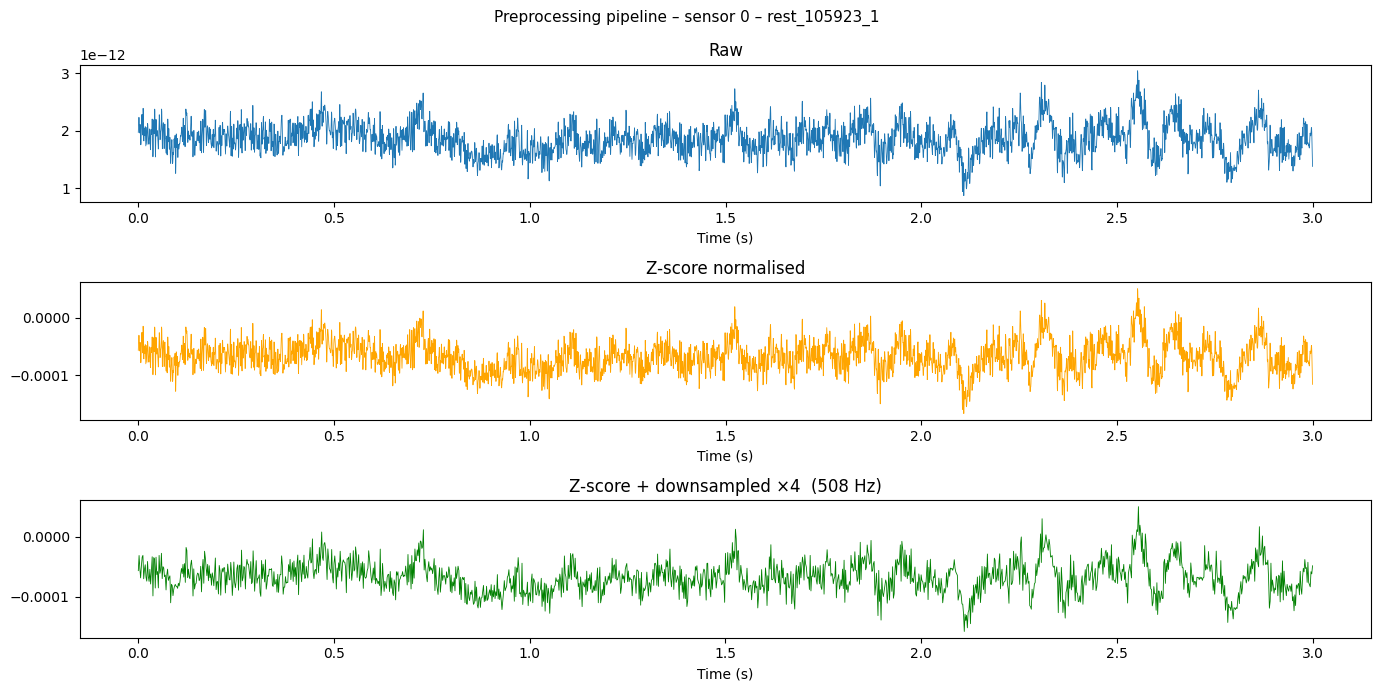

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=False)
t_raw = np.arange(T_SAMPLES) / SAMPLE_RATE
t_ds  = np.arange(T_SAMPLES // 4) / (SAMPLE_RATE // 4)

axes[0].plot(t_raw, raw[0, :T_SAMPLES],        linewidth=0.6)
axes[0].set_title('Raw')
axes[0].ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

axes[1].plot(t_raw, norm[0, :T_SAMPLES],       linewidth=0.6, color='orange')
axes[1].set_title('Z-score normalised')

axes[2].plot(t_ds,  ds[0, :T_SAMPLES // 4],   linewidth=0.6, color='green')
axes[2].set_title(f'Z-score + downsampled ×4  ({SAMPLE_RATE//4} Hz)')

for ax in axes:
    ax.set_xlabel('Time (s)')

fig.suptitle(f'Preprocessing pipeline – sensor 0 – {sample_file.stem}', fontsize=11)
plt.tight_layout()
plt.show()

## 8. Cross-subject variability

Compare the mean sensor amplitude across subjects for the same task to get a sense of how much the signal varies between individuals.

Subjects in Cross/train: ['113922', '164636']


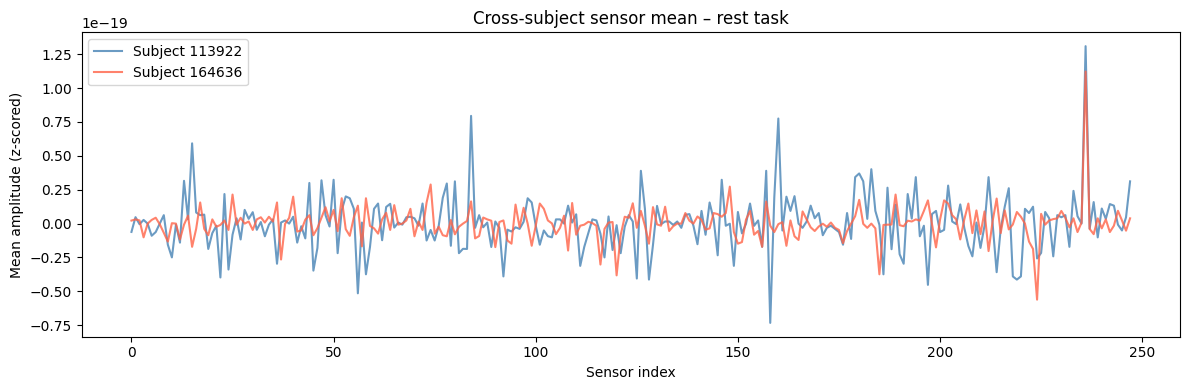

In [11]:
cross_train_files = list_files(CROSS_TRAIN)

# gather one 'rest' file per subject
rest_per_subject = defaultdict(list)
for f in cross_train_files:
    if f.name.startswith('rest'):
        parts = f.stem.split('_')
        subj = next(p for p in parts if p.isdigit() and len(p) == 6)
        rest_per_subject[subj].append(f)

print('Subjects in Cross/train:', list(rest_per_subject.keys()))

fig, ax = plt.subplots(figsize=(12, 4))
colors = ['steelblue', 'tomato']
for (subj, files), color in zip(rest_per_subject.items(), colors):
    m = zscore_normalize(load_h5(files[0]))
    mean_per_sensor = m.mean(axis=1)  # avg over time
    ax.plot(mean_per_sensor, label=f'Subject {subj}', alpha=0.8, color=color)

ax.set_xlabel('Sensor index')
ax.set_ylabel('Mean amplitude (z-scored)')
ax.set_title('Cross-subject sensor mean – rest task')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Class balance check – intra train

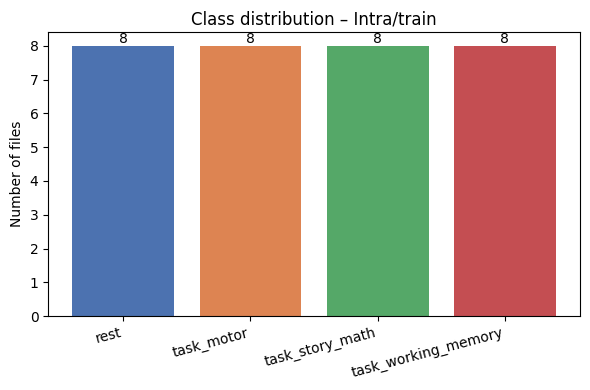

In [12]:
intra_files = list_files(INTRA_TRAIN)
label_counts = defaultdict(int)
for f in intra_files:
    label_counts[LABEL_NAMES[get_label(f)]] += 1

fig, ax = plt.subplots(figsize=(6, 4))
tasks = list(label_counts.keys())
counts = [label_counts[t] for t in tasks]
bars = ax.bar(tasks, counts, color=['#4C72B0','#DD8452','#55A868','#C44E52'])
ax.bar_label(bars)
ax.set_ylabel('Number of files')
ax.set_title('Class distribution – Intra/train')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

## 10. Summary

| Property | Value |
|---|---|
| Sensors | 248 magnetometers |
| Time steps per file | 35,624 |
| Sample rate | 2034 Hz |
| Duration per file | ~17.5 s |
| Classes | rest / motor / math / memory |
| Intra subjects | 1 (105923) |
| Cross train subjects | 2 (113922, 164636) |
| Cross test subjects | 3 (unseen) |

### Preprocessing decisions
- **Normalisation**: Z-score per sensor (time-wise) – removes mean and scales variance, essential given the femtoTesla magnitude.
- **Downsampling**: factor 4 → 508 Hz effective rate. Neuroscience research rarely requires >300 Hz for cognitive-task discrimination; this reduces sequence length from 35k to ~9k, making training faster.
